# Download K2 Variable Stars Data from Campaigns

In [37]:
import lightkurve as lk
from lightkurve import search_lightcurve
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


In [38]:
df = pd.read_csv(r"../assets/data/asu-cleaned.tsv", sep='\t')


In [39]:
df


,EPIC,Type,VRange,Per,Amp,LC,Info,Simbad,_RA,_DE
0,,,%,d,%,,,,deg,deg
1,---------,--,------,---------,-----,--,----------------------------------------------...,------,---------,---------
2,201122454,AP,0.84,,,LC,...,Simbad,176.71052,-05.97357
3,201123619,AP,1.31,,,LC,...,Simbad,176.79939,-05.94390
4,201126062,AP,1.82,,,LC,...,Simbad,176.73978,-05.88346
...,...,...,...,...,...,...,...,...,...,...
8392,202139931,AP,0.41,,,LC,...,Simbad,101.82189,+26.06677
8393,202139932,AP,3.68,,,LC,...,Simbad,102.80444,+26.06780
8394,202139979,QP,7.03,1.992561,2.40,LC,...,Simbad,101.13129,+27.65499
8395,210282472,QP,10.08,0.709911,2.20,LC,1019 (RR Lyrae/Red Giant) ...,Simbad,173.23250,-00.55817


In [43]:
from astropy.io import fits

hdul = fits.open("../assets/data/lightcurves/hlsp_k2varcat_k2_lightcurve_202059070-c00_kepler_v2_llc.fits")
hdul.info()


Filename: ../assets/data/lightcurves/hlsp_k2varcat_k2_lightcurve_202059070-c00_kepler_v2_llc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      67   ()      
  1                1 BinTableHDU     26   1454R x 5C   [D, E, E, E, E]   


In [44]:
hdul


[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x14ce1d810>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x14dda36b0>]

In [45]:
# Light curve data is usually in extension 1
data = hdul[1].data
data


FITS_rec([(1940.0280118 , 1233.5972, 26.70977 , 1.0284357, 0.02082971),
          (1940.04844349, 1226.5762, 25.792166, 1.00699  , 0.01969468),
          (1940.06887498, 1218.72  , 27.040632, 1.0333587, 0.02118868),
          ...,
          (1972.14664745, 1330.897 , 28.884472, 1.0016643, 0.02193929),
          (1972.16707924, 1332.01  , 29.98771 , 1.015696 , 0.02309633),
          (1972.18751114, 1319.3499, 30.731415, 1.0077314, 0.02348353)],
         dtype=(numpy.record, [('TIME', '>f8'), ('APTFLUX', '>f4'), ('APTFLUX_ERR', '>f4'), ('DETFLUX', '>f4'), ('DETFLUX_ERR', '>f4')]))

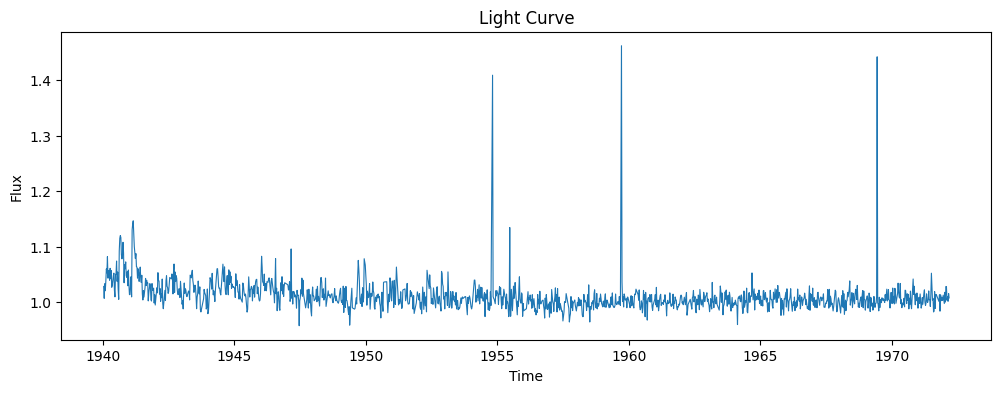

In [46]:
time = data["TIME"]
flux = data["DETFLUX"]       # or data["APTFLUX"]
flux_err = data["DETFLUX_ERR"]  # or data["APTFLUX_ERR"]

mask = np.isfinite(time) & np.isfinite(flux)
if flux_err is not None:
    mask &= np.isfinite(flux_err)

time = time[mask]
flux = flux[mask]
flux_err = flux_err[mask]

plt.figure(figsize=(12, 4))
plt.plot(time, flux, linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Light Curve")
plt.show()
